NAMA : Mohammad Iqbal Surya Ramadhan

NIM  : 210411100002

MATA KULIAH : Pencarian dan Penambangan Web - A

# Tugas 8 : Clustering Berita menggunakan Fuzzy C-Means


# Test fuzzy c-means 1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas-PPWA/Hasil_Prepros.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal
0,"Nunggak 8 Bulan, Segini Pajak Ford Mustang Mil...","Kamis, 19 Sep 2024 13:05 WIB",Jakarta - Bareskrim Polri menyita aset senilai...,Otomotif,Jakarta Bareskrim Polri menyita aset senilai ...,jakarta bareskrim polri menyita aset senilai ...,"['jakarta', 'bareskrim', 'polri', 'menyita', '...",jakarta bareskrim polri menyita aset senilai r...
1,Bos Ford Kaget usai Jajal Mobil China: Mereka ...,"Kamis, 19 Sep 2024 12:33 WIB","Jakarta - Chief Executive Officer (CEO) Ford, ...",Otomotif,Jakarta Chief Executive Officer CEO Ford Jim ...,jakarta chief executive officer ceo ford jim ...,"['jakarta', 'chief', 'executive', 'officer', '...",jakarta chief executive officer ceo ford jim f...
2,"Tarif Tol Dalam Kota Naik Jadi Segini, Berlaku...","Kamis, 19 Sep 2024 12:08 WIB",Jakarta - Jasa Marga mengumumkan kenaikan tari...,Otomotif,Jakarta Jasa Marga mengumumkan kenaikan tarif...,jakarta jasa marga mengumumkan kenaikan tarif...,"['jakarta', 'jasa', 'marga', 'mengumumkan', 'k...",jakarta jasa marga mengumumkan kenaikan tarif ...
3,Pak RT Aleix Espargaro Tak Sabar Balapan Terak...,"Kamis, 19 Sep 2024 11:40 WIB","Jakarta - Pebalap Aprilia asal Spanyol, Aleix ...",Otomotif,Jakarta Pebalap Aprilia asal Spanyol Aleix Es...,jakarta pebalap aprilia asal spanyol aleix es...,"['jakarta', 'pebalap', 'aprilia', 'asal', 'spa...",jakarta pebalap aprilia spanyol aleix espargar...
4,Angkot Listrik Bakal Diuji Coba di Jakarta,"Kamis, 19 Sep 2024 11:18 WIB",Jakarta - PT Transportasi Jakarta (TransJakart...,Otomotif,Jakarta PT Transportasi Jakarta TransJakarta ...,jakarta pt transportasi jakarta transjakarta ...,"['jakarta', 'pt', 'transportasi', 'jakarta', '...",jakarta pt transportasi jakarta transjakarta k...


In [ ]:
!pip install scikit-fuzzy
# Import libraries yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 11.2 MB/s eta 0:00:00


In [ ]:
texts = df['stopword_removal']

In [ ]:
# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

In [ ]:
# Normalisasi fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(tfidf_array)

algoritma Fuzzy C-Means Clustering

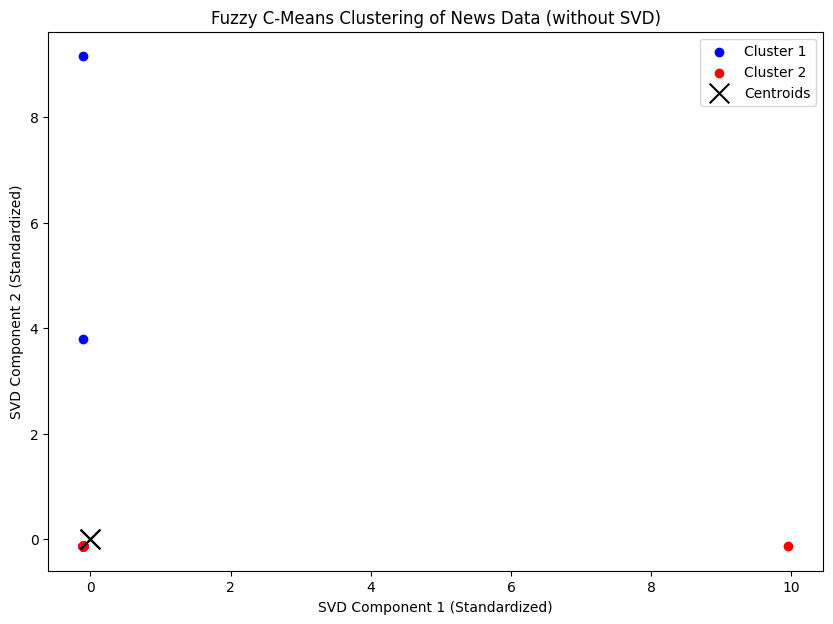

In [ ]:
n_clusters = 2  # Jumlah cluster yang diinginkan
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    X_scaled.T, c=n_clusters, m=2, error=0.001, maxiter=1000, init=None
)

# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_labels == i, 0], X_scaled[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=200, color='k', label='Centroids')

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (without SVD)')
plt.legend()
plt.show()

Fuzzy C-Means Clustering untuk mengelompokkan data dengan visualisasi hasil dan evaluasi kinerja klasterisasi menggunakan nilai Fuzzy Partition Coefficient (FPC).

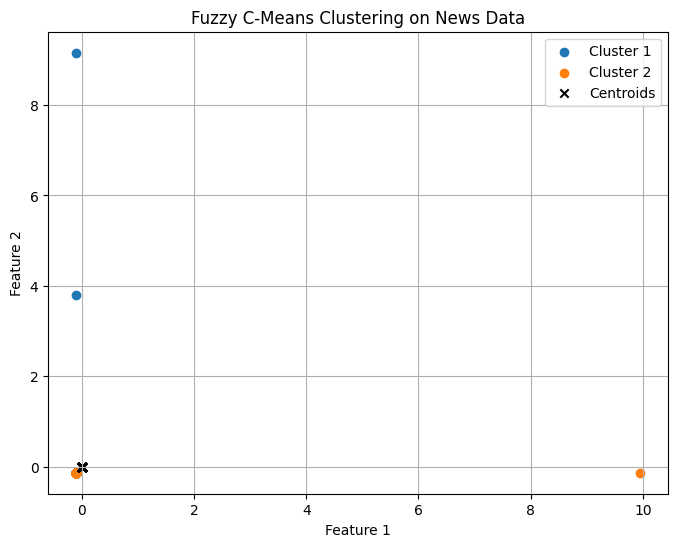

Fuzzy Partition Coefficient (FPC): 0.5000000000009149


In [ ]:
# Tentukan jumlah cluster dan parameter fuzziness
n_clusters = 2
m = 2  # Parameter fuzziness

# Terapkan Fuzzy C-Means
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    X_scaled.T, n_clusters, m, error=0.001, maxiter=1000, init=None
)

# Tentukan keanggotaan cluster
cluster_membership = np.argmax(u, axis=0)

# Visualisasi Hasil Clustering
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    plt.scatter(X_scaled[cluster_membership == i, 0], X_scaled[cluster_membership == i, 1], label=f'Cluster {i+1}')

# Tampilkan centroid
plt.scatter(cntr[0], cntr[1], marker='x', color='black', label='Centroids')

plt.title('Fuzzy C-Means Clustering on News Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# Evaluasi Hasil
print("Fuzzy Partition Coefficient (FPC):", fpc)


# Test fuzzy c-means 2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas-PPWA/Hasil_Prepros.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal
0,"Nunggak 8 Bulan, Segini Pajak Ford Mustang Mil...","Kamis, 19 Sep 2024 13:05 WIB",Jakarta - Bareskrim Polri menyita aset senilai...,Otomotif,Jakarta Bareskrim Polri menyita aset senilai ...,jakarta bareskrim polri menyita aset senilai ...,"['jakarta', 'bareskrim', 'polri', 'menyita', '...",jakarta bareskrim polri menyita aset senilai r...
1,Bos Ford Kaget usai Jajal Mobil China: Mereka ...,"Kamis, 19 Sep 2024 12:33 WIB","Jakarta - Chief Executive Officer (CEO) Ford, ...",Otomotif,Jakarta Chief Executive Officer CEO Ford Jim ...,jakarta chief executive officer ceo ford jim ...,"['jakarta', 'chief', 'executive', 'officer', '...",jakarta chief executive officer ceo ford jim f...
2,"Tarif Tol Dalam Kota Naik Jadi Segini, Berlaku...","Kamis, 19 Sep 2024 12:08 WIB",Jakarta - Jasa Marga mengumumkan kenaikan tari...,Otomotif,Jakarta Jasa Marga mengumumkan kenaikan tarif...,jakarta jasa marga mengumumkan kenaikan tarif...,"['jakarta', 'jasa', 'marga', 'mengumumkan', 'k...",jakarta jasa marga mengumumkan kenaikan tarif ...
3,Pak RT Aleix Espargaro Tak Sabar Balapan Terak...,"Kamis, 19 Sep 2024 11:40 WIB","Jakarta - Pebalap Aprilia asal Spanyol, Aleix ...",Otomotif,Jakarta Pebalap Aprilia asal Spanyol Aleix Es...,jakarta pebalap aprilia asal spanyol aleix es...,"['jakarta', 'pebalap', 'aprilia', 'asal', 'spa...",jakarta pebalap aprilia spanyol aleix espargar...
4,Angkot Listrik Bakal Diuji Coba di Jakarta,"Kamis, 19 Sep 2024 11:18 WIB",Jakarta - PT Transportasi Jakarta (TransJakart...,Otomotif,Jakarta PT Transportasi Jakarta TransJakarta ...,jakarta pt transportasi jakarta transjakarta ...,"['jakarta', 'pt', 'transportasi', 'jakarta', '...",jakarta pt transportasi jakarta transjakarta k...


In [ ]:
!pip install scikit-fuzzy
# Import libraries yang diperlukan
import numpy as np
import pandas as pd
import skfuzzy as fuzz
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler

In [ ]:
texts = df['stopword_removal']

In [ ]:
# Preprocessing: TF-IDF
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(texts)
tfidf_array = tfidf_matrix.toarray()

In [ ]:
# Reduksi dimensi menggunakan SVD
svd = TruncatedSVD(n_components=5, random_state=0)
data_2d = svd.fit_transform(tfidf_array)

In [ ]:
data_2d.shape

(100, 5)

In [ ]:
# Normalisasi dengan StandardScaler
scaler = StandardScaler()
data_2d_normalized = scaler.fit_transform(data_2d)

In [ ]:
# Tetapkan random seed u
np.random.seed(25)

# Fuzzy C-Means Clustering
n_clusters = 2
cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(
    data_2d_normalized.T, c=n_clusters, m=9, error=0.001, maxiter=1000, init=None
)

# Menentukan cluster untuk setiap data berdasarkan keanggotaan tertinggi
cluster_labels = np.argmax(u, axis=0)

In [ ]:
# Menambahkan hasil klasterisasi ke dalam DataFrame
df['Cluster'] = cluster_labels

# Menampilkan jumlah data pada setiap cluster
cluster_counts = df['Cluster'].value_counts()
print("Jumlah data pada setiap cluster:")
print(cluster_counts)

df_filtered = df[['judul', 'kategori', 'Cluster']]
df_filtered




Jumlah data pada setiap cluster:
Cluster
1    68
0    32
Name: count, dtype: int64


,judul,kategori,Cluster
0,"Nunggak 8 Bulan, Segini Pajak Ford Mustang Mil...",Otomotif,0
1,Bos Ford Kaget usai Jajal Mobil China: Mereka ...,Otomotif,0
2,"Tarif Tol Dalam Kota Naik Jadi Segini, Berlaku...",Otomotif,1
3,Pak RT Aleix Espargaro Tak Sabar Balapan Terak...,Otomotif,1
4,Angkot Listrik Bakal Diuji Coba di Jakarta,Otomotif,1
...,...,...,...
95,Suku Bunga BI Dipangkas Jadi 6% Dinilai Berani,Keuangan,0
96,Prabowo Ingatkan Perang Makin Marak hingga Sal...,Keuangan,1
97,"Ditjen Pajak Respons Kabar 6 Juta NPWP Bocor, ...",Keuangan,0
98,Buruh Waswas Kisruh di Kadin Pengaruhi Penetap...,Keuangan,1


In [ ]:
filename = 'HasilfilteredSvd.csv'  # Define the filename
df_filtered.to_csv(filename, index=False)
print(f"CSV file '{filename}' saved successfully!")

CSV file 'HasilfilteredSvd.csv' saved successfully!


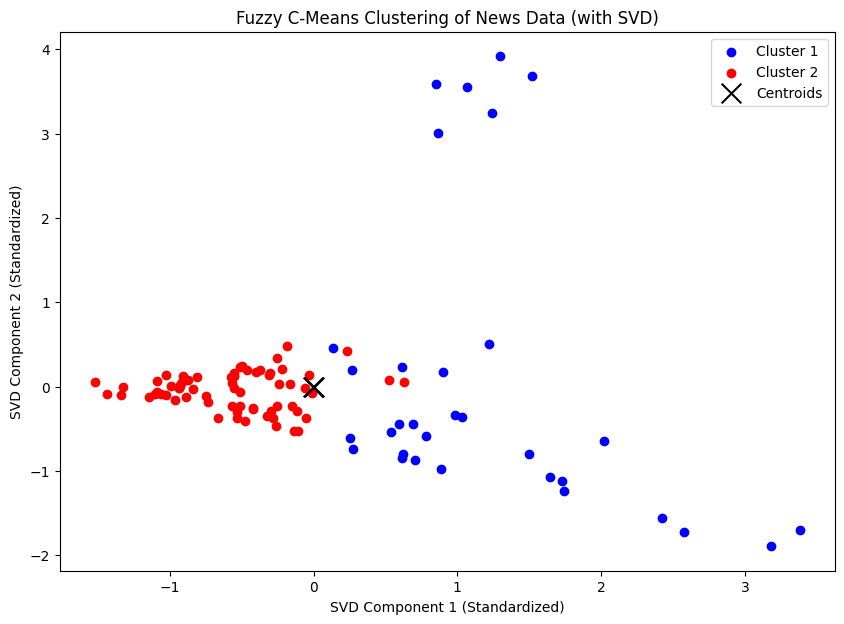

In [ ]:
# Visualisasi hasil klasterisasi
plt.figure(figsize=(10, 7))
colors = ['b', 'r']
for i in range(n_clusters):
    plt.scatter(data_2d_normalized[cluster_labels == i, 0], data_2d_normalized[cluster_labels == i, 1],
                color=colors[i], label=f'Cluster {i+1}')

# Menampilkan pusat cluster
plt.scatter(cntr[:, 0], cntr[:, 1], marker='x', s=200, color='k', label='Centroids')

plt.xlabel('SVD Component 1 (Standardized)')
plt.ylabel('SVD Component 2 (Standardized)')
plt.title('Fuzzy C-Means Clustering of News Data (with SVD)')
plt.legend()
plt.show()

# Test fuzzy c-means 3

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/My Drive/PPWA/report/Tugas-PPWA/Hasil_Prepros.csv")
df.head()

,judul,tanggal,isi,kategori,cleansing,case_folding,tokenize,stopword_removal
0,"Nunggak 8 Bulan, Segini Pajak Ford Mustang Mil...","Kamis, 19 Sep 2024 13:05 WIB",Jakarta - Bareskrim Polri menyita aset senilai...,Otomotif,Jakarta Bareskrim Polri menyita aset senilai ...,jakarta bareskrim polri menyita aset senilai ...,"['jakarta', 'bareskrim', 'polri', 'menyita', '...",jakarta bareskrim polri menyita aset senilai r...
1,Bos Ford Kaget usai Jajal Mobil China: Mereka ...,"Kamis, 19 Sep 2024 12:33 WIB","Jakarta - Chief Executive Officer (CEO) Ford, ...",Otomotif,Jakarta Chief Executive Officer CEO Ford Jim ...,jakarta chief executive officer ceo ford jim ...,"['jakarta', 'chief', 'executive', 'officer', '...",jakarta chief executive officer ceo ford jim f...
2,"Tarif Tol Dalam Kota Naik Jadi Segini, Berlaku...","Kamis, 19 Sep 2024 12:08 WIB",Jakarta - Jasa Marga mengumumkan kenaikan tari...,Otomotif,Jakarta Jasa Marga mengumumkan kenaikan tarif...,jakarta jasa marga mengumumkan kenaikan tarif...,"['jakarta', 'jasa', 'marga', 'mengumumkan', 'k...",jakarta jasa marga mengumumkan kenaikan tarif ...
3,Pak RT Aleix Espargaro Tak Sabar Balapan Terak...,"Kamis, 19 Sep 2024 11:40 WIB","Jakarta - Pebalap Aprilia asal Spanyol, Aleix ...",Otomotif,Jakarta Pebalap Aprilia asal Spanyol Aleix Es...,jakarta pebalap aprilia asal spanyol aleix es...,"['jakarta', 'pebalap', 'aprilia', 'asal', 'spa...",jakarta pebalap aprilia spanyol aleix espargar...
4,Angkot Listrik Bakal Diuji Coba di Jakarta,"Kamis, 19 Sep 2024 11:18 WIB",Jakarta - PT Transportasi Jakarta (TransJakart...,Otomotif,Jakarta PT Transportasi Jakarta TransJakarta ...,jakarta pt transportasi jakarta transjakarta ...,"['jakarta', 'pt', 'transportasi', 'jakarta', '...",jakarta pt transportasi jakarta transjakarta k...


In [ ]:
!pip install scikit-fuzzy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
import skfuzzy as fuzz

In [ ]:
# Lakukan preprocessing data menggunakan TF-IDF
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df['stopword_removal']).toarray()

In [ ]:
lda = LatentDirichletAllocation(n_components=9)
X_topic = lda.fit_transform(X)

In [ ]:
# Implementasikan Fuzzy C-Means menggunakan Fuzzy library
n_clusters = 2
m = 8  # Fuzzy coefficient
max_iter = 1000
tol = 0.05

cntr, u, _, _, _, _, _ = fuzz.cluster.cmeans(X_topic.T, n_clusters, m, max_iter, tol)

# Dapatkan label cluster untuk setiap data
labels = np.argmax(u, axis=0)

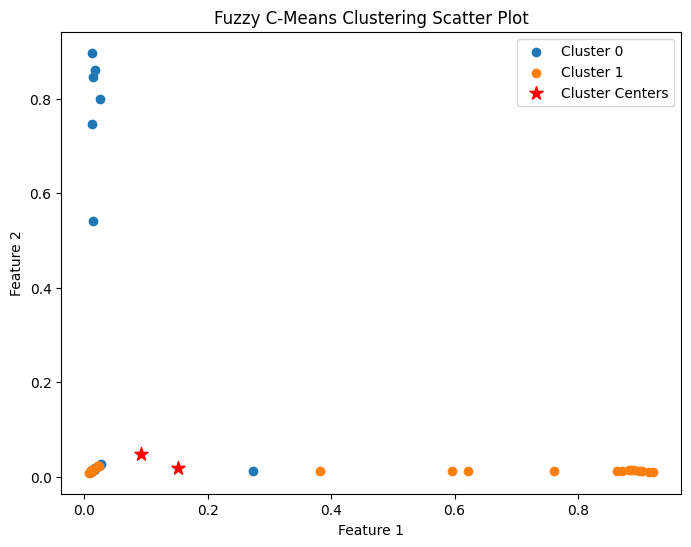

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Buat plot scatter
plt.figure(figsize=(8, 6))
for i in range(n_clusters):
    cluster_data = X_topic[labels == i]
    plt.scatter(cluster_data[:, 0], cluster_data[:, 1], label=f'Cluster {i}')
plt.scatter(cntr[:, 0], cntr[:, 1], s=100, c='red', marker='*', label='Cluster Centers')
plt.title('Fuzzy C-Means Clustering Scatter Plot')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()